# 01 ,  Análisis exploratorio de recursos base

**TFM Inga-Español.** Este notebook realiza el análisis exploratorio de datos (EDA) sobre los cinco recursos lingüísticos primarios OCR-extraídos que sostienen el corpus bidialectal (Alto Putumayo y Medio Putumayo) del presente trabajo.

**Salidas:**
- `datos/diccionario_inga.jsonl` ,  entradas léxicas estructuradas.
- `datos/estadisticas_corpus.json` ,  conteos agregados.
- `entrega1/figuras/fig07_distribucion_longitud_nt.png` ,  Figura 7 del documento.

## Imports y configuración de rutas

In [1]:
from pathlib import Path
import json, re
import matplotlib.pyplot as plt
import pandas as pd

OCR_ROOT = Path('/Users/william-santos/Documents/UNIR/mistral-ocr-extractor/output/inga-kichwa')
DATA_OUT = Path('/Users/william-santos/Documents/UNIR/tfm/datos')
FIG_OUT  = Path('/Users/william-santos/Documents/UNIR/tfm/entrega1/figuras')
DATA_OUT.mkdir(parents=True, exist_ok=True)
FIG_OUT.mkdir(parents=True, exist_ok=True)

RESOURCES = {
    'diccionario':              OCR_ROOT / '756362843-Diccionario-Inga' / 'content.md',
    'gramatica_pedagogica':     OCR_ROOT / 'Inga Kichwa; Una Gramatica Pedagogical del Inga (parts 1 & 2) (Levinsohn)' / 'content.md',
    'apendice_morfosintactico': OCR_ROOT / 'rosettaproject_inb_morsyn-1' / 'content.md',
    'nuevo_testamento':         OCR_ROOT / '00-WNTinb-web' / 'content.md',
    'antihua_pacay':            OCR_ROOT / 'inj-AntihuaPacay' / 'content.md',
}
for name, p in RESOURCES.items():
    print(f'{name:30s} {"OK" if p.exists() else "MISS"}  {p}')

diccionario                    OK  /Users/william-santos/Documents/UNIR/mistral-ocr-extractor/output/inga-kichwa/756362843-Diccionario-Inga/content.md
gramatica_pedagogica           OK  /Users/william-santos/Documents/UNIR/mistral-ocr-extractor/output/inga-kichwa/Inga Kichwa; Una Gramatica Pedagogical del Inga (parts 1 & 2) (Levinsohn)/content.md
apendice_morfosintactico       OK  /Users/william-santos/Documents/UNIR/mistral-ocr-extractor/output/inga-kichwa/rosettaproject_inb_morsyn-1/content.md
nuevo_testamento               OK  /Users/william-santos/Documents/UNIR/mistral-ocr-extractor/output/inga-kichwa/00-WNTinb-web/content.md
antihua_pacay                  OK  /Users/william-santos/Documents/UNIR/mistral-ocr-extractor/output/inga-kichwa/inj-AntihuaPacay/content.md


## Conteos básicos por recurso

In [2]:
def count_basic(md_path):
    text = md_path.read_text(encoding='utf-8')
    return {
        'chars': len(text),
        'words': len(text.split()),
        'lines': text.count('\n') + 1,
        'pages': text.count('<!-- Page '),
    }

stats = {name: count_basic(p) for name, p in RESOURCES.items()}
stats_df = pd.DataFrame(stats).T
print(stats_df.to_string())
print(f'\nTotal paginas OCR: {stats_df["pages"].sum()}')

                            chars   words  lines  pages
diccionario                469272   72212  19152    177
gramatica_pedagogica       326093   54172   7434    228
apendice_morfosintactico    31344    5130    951     26
nuevo_testamento          1474063  178385  17759    595
antihua_pacay               65311    9767   1302     68

Total paginas OCR: 1094


## Parseo del diccionario a JSONL

In [3]:
dict_text = RESOURCES['diccionario'].read_text(encoding='utf-8')

# Patron: lema [categoria gramatical] glosa en espanol
# Categorias comunes en el diccionario: adj, adv, s, v.i, v.t, interj, conj, dem, pron, num
ABBREV = r'(adj|adv|s|v\.i|v\.t|interj|conj|dem|intens|pron|num|vbo)'
entry_re = re.compile(
    rf'^([a-zA-Zu00e1u00e9u00edu00f3u00fau00f1u00ef][\w\-\u0300-\u036f]*)\s+({ABBREV})\b\s+(.+?)$',
    re.MULTILINE
)
entries = []
for m in entry_re.finditer(dict_text):
    lema = m.group(1)
    cat  = m.group(2)
    glosa = m.group(3).strip()[:300]
    if 2 <= len(lema) <= 40 and len(glosa) >= 2:
        entries.append({'lema': lema, 'cat': cat, 'glosa': glosa})

print(f'Entradas lexicas detectadas (heuristica conservadora): {len(entries)}')
for e in entries[:5]:
    print(' ', e)

with open(DATA_OUT / 'diccionario_inga.jsonl', 'w', encoding='utf-8') as f:
    for e in entries:
        f.write(json.dumps(e, ensure_ascii=False) + '\n')
print(f'Guardado: {DATA_OUT / "diccionario_inga.jsonl"}')

Entradas lexicas detectadas (heuristica conservadora): 817
  {'lema': 'Aku', 'cat': 'interj', 'glosa': 'interj'}
  {'lema': 'achala', 'cat': 'adj', 'glosa': 'adj'}
  {'lema': 'Achalai', 'cat': 'interj', 'glosa': 'interj'}
  {'lema': 'Achichai', 'cat': 'interj', 'glosa': 'interj'}
  {'lema': 'achka', 'cat': 'adj', 'glosa': 'adj'}
Guardado: /Users/william-santos/Documents/UNIR/tfm/datos/diccionario_inga.jsonl


## Estimacion de versiculos en el Nuevo Testamento

In [4]:
nt_text = RESOURCES['nuevo_testamento'].read_text(encoding='utf-8')

# Los versiculos en el NT Wycliffe suelen estar numerados al inicio de un renglon.
# Buscamos secuencias '\nN ' o 'N ' al inicio de linea con un numero de 1-3 digitos.
verse_re = re.compile(r'(?m)^(\d{1,3})\s+[A-Z\u00c0-\u024fI]', re.UNICODE)
verses = verse_re.findall(nt_text)
print(f'Numero aproximado de versiculos detectados: {len(verses)}')

Numero aproximado de versiculos detectados: 2837


## Figura 7. Distribucion de longitudes del NT Inga

Versiculos con longitud valida (3 < palabras < 80): 2791


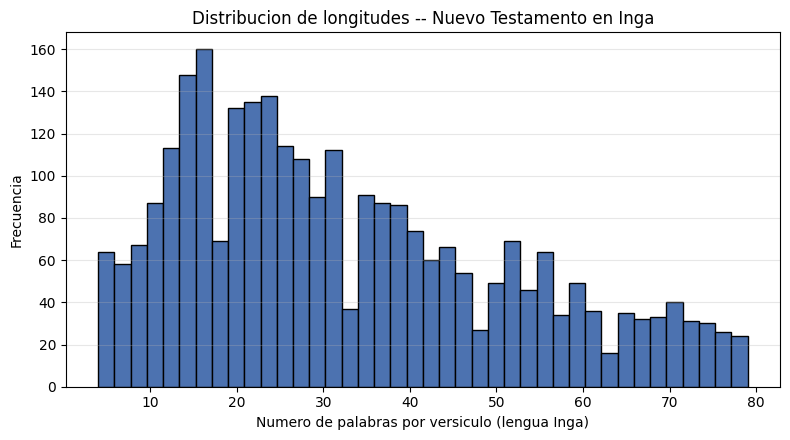

Figura guardada: /Users/william-santos/Documents/UNIR/tfm/entrega1/figuras/fig07_distribucion_longitud_nt.png
Longitud media: 32.8 palabras por versiculo


In [5]:
# Extraemos cada 'versiculo' aproximado como el texto entre dos marcadores numericos.
verse_segments = re.split(r'(?m)^\d{1,3}\s+', nt_text)
lengths = [len(s.split()) for s in verse_segments if 3 < len(s.split()) < 80]
print(f'Versiculos con longitud valida (3 < palabras < 80): {len(lengths)}')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(lengths, bins=40, edgecolor='black', color='#4C72B0')
ax.set_xlabel('Numero de palabras por versiculo (lengua Inga)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribucion de longitudes -- Nuevo Testamento en Inga')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig_path = FIG_OUT / 'fig07_distribucion_longitud_nt.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {fig_path}')
if lengths:
    media = sum(lengths)/len(lengths)
    print(f'Longitud media: {media:.1f} palabras por versiculo')

## Estadisticas agregadas

In [6]:
summary = {
    'recursos': {name: count_basic(p) for name, p in RESOURCES.items()},
    'total_paginas_ocr': int(stats_df['pages'].sum()),
    'diccionario_entradas_detectadas': len(entries),
    'nt_versiculos_aproximados': len(verses),
    'nt_versiculos_longitud_valida': len(lengths),
    'nt_longitud_media_palabras_inga': round(sum(lengths)/len(lengths), 2) if lengths else 0,
}
out_json = DATA_OUT / 'estadisticas_corpus.json'
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print(f'Stats guardados: {out_json}')
print(json.dumps(summary, ensure_ascii=False, indent=2))

Stats guardados: /Users/william-santos/Documents/UNIR/tfm/datos/estadisticas_corpus.json
{
  "recursos": {
    "diccionario": {
      "chars": 469272,
      "words": 72212,
      "lines": 19152,
      "pages": 177
    },
    "gramatica_pedagogica": {
      "chars": 326093,
      "words": 54172,
      "lines": 7434,
      "pages": 228
    },
    "apendice_morfosintactico": {
      "chars": 31344,
      "words": 5130,
      "lines": 951,
      "pages": 26
    },
    "nuevo_testamento": {
      "chars": 1474063,
      "words": 178385,
      "lines": 17759,
      "pages": 595
    },
    "antihua_pacay": {
      "chars": 65311,
      "words": 9767,
      "lines": 1302,
      "pages": 68
    }
  },
  "total_paginas_ocr": 1094,
  "diccionario_entradas_detectadas": 817,
  "nt_versiculos_aproximados": 2837,
  "nt_versiculos_longitud_valida": 2791,
  "nt_longitud_media_palabras_inga": 32.75
}


## Resumen

Los outputs de este notebook alimentan la Tabla 3 y la Figura 7 del Capitulo 4.1.2 del documento de la Entrega 1. El JSONL del diccionario constituye la base del indice lexico del sistema RAG (Capitulo 3.3) que se implementa en las Fases 3 y 5 del proyecto.